In [1]:
# ── Cell 1 : Setup & Imports ──────────
import json
import pickle
import pathlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

project_root = next(
    p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
    if (p / "pyproject.toml").exists()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src import marginal_comparison as mc

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 4)
print("Imports successful!")

Imports successful!


In [2]:
# ── Cell 2 : Locate Sibling Sampler Runs ──────────
# This notebook sits in a <chains>/<k>_comp/ folder and compares the NUTS, HMC and
# bayesm runs that live beside it: <sampler>/<run>/results/posterior_raw.pkl.

def _resolve_dir():
    nb = globals().get("__vsc_ipynb_file__")
    return pathlib.Path(nb).resolve().parent if nb else pathlib.Path.cwd()

XCOMP_DIR = _resolve_dir()
hits = sorted(XCOMP_DIR.glob("*/*/results/posterior_raw.pkl"))
if not hits:
    raise FileNotFoundError(
        f"No <sampler>/<run>/results/posterior_raw.pkl under:\n  {XCOMP_DIR}\n"
        f"This notebook must sit in a <chains>/<k>_comp/ folder. In VS Code set\n"
        f'  "jupyter.notebookFileRoot": "${{fileDirname}}"  and restart the kernel.'
    )

runs = {}
for h in hits:
    sampler = h.parents[2].name          # NUTS / HMC / bayesm
    runs.setdefault(sampler, h.parent)   # first run's results dir per sampler

meta = json.load(open(next(iter(runs.values())) / "meta.json"))
SCENARIO = meta["scenario"]
K_MODEL  = int(meta["k_model"])
K_TRUE   = int(meta["k_true"])
CHAINS   = int(meta["chains"])

print(f"x_comp folder : {XCOMP_DIR}")
print(f"scenario={SCENARIO}  K_MODEL={K_MODEL}  K_TRUE={K_TRUE}")
print(f"samplers found: {list(runs)}")

models = [mc.load_sampler(rd, name) for name, rd in runs.items()]
for m in models:
    print(f"  {m['name']:<8} mu {m['mu'].shape}")

x_comp folder : C:\Users\ThinkPad\Desktop\Repositories\HierarchicalBayesianMNL\hbmnl_mixture_experiments\2_chains\1_comp
scenario=1comp  K_MODEL=5  K_TRUE=1
samplers found: ['bayesm', 'HMC', 'NUTS']


  bayesm   mu (2, 10000, 5, 4)
  HMC      mu (2, 10000, 5, 4)
  NUTS     mu (2, 10000, 5, 4)


In [3]:
# ── Cell 3 : Ground Truth & Grids ──────────
# Grids are anchored to the FITTED models' live-component support (union over
# samplers); the True DGP is an overlay only, never used to set the bounds.
raw = json.load(open(project_root / "data" / "simulated" / "mixture" / f"{SCENARIO}.json"))
P = int(raw["n_params"])
param_names = raw.get("param_names") or [f"Param_{i}" for i in range(P)]
true_model = mc.true_dgp_model(raw)

grids = mc.build_grids(models, K_true=K_TRUE, n_grid=1000, n_sigma=4)
print("Grid extents (fitted-support, live components):")
for j, pj in enumerate(param_names):
    print(f"  {pj:<10} [{grids[j][0]:+.2f}, {grids[j][-1]:+.2f}]")

Grid extents (fitted-support, live components):
  Alt 1      [-3.81, +6.46]
  Alt 2      [-3.68, +11.55]
  Alt 3      [-2.81, +9.27]
  Price      [-7.29, +2.08]


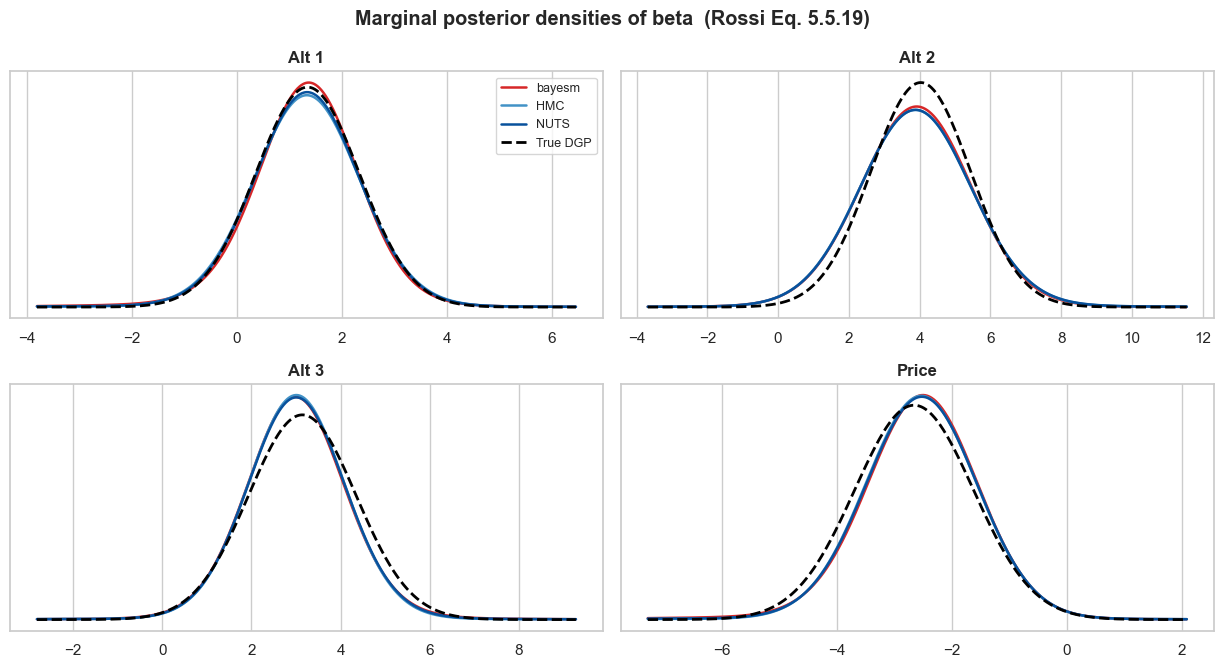

In [4]:
# ── Cell 4 : Marginal Densities (Rossi Eq. 5.5.19) ──────────
dens      = {m["name"]: mc.marginal_density(m, grids) for m in models}
dens_true = mc.marginal_density(true_model, grids)
# True DGP = black (dashed reference), bayesm = red, Liesel samplers = distinct
# shades of blue (ColorBrewer Blues: dark -> light).
colors = {"NUTS": "#08519c", "HMC": "#4292c6", "iwls": "#9ecae1", "bayesm": "#d62728"}
TRUE_COLOR = "#000000"

ncols = min(P, 2)
nrows = int(np.ceil(P / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 6.2, nrows * 3.4), squeeze=False)
ax = axes.ravel()
for j, pj in enumerate(param_names):
    for name, d in dens.items():
        ax[j].plot(grids[j], d[j], lw=1.8, label=name, color=colors.get(name, "#7f7f7f"))
    ax[j].plot(grids[j], dens_true[j], lw=2.0, ls="--", color=TRUE_COLOR, label="True DGP")
    ax[j].set_title(pj, fontweight="bold")
    ax[j].set_yticks([])
for j in range(P, len(ax)):
    ax[j].set_visible(False)
ax[0].legend(fontsize=9)
fig.suptitle("Marginal posterior densities of beta  (Rossi Eq. 5.5.19)", fontweight="bold")
fig.tight_layout()
plt.show()

In [5]:
# ── Cell 5 : Density Distances vs True DGP ──────────
# Every sampler's marginal is compared ONLY to the True DGP marginal (never to
# another sampler). Metrics: Hellinger (primary), KL(model||true), Jensen-Shannon,
# total-variation, Wasserstein-1. All label-invariant - relabeling/ECR would not
# change them.
display(mc.distance_table(models, true_model, grids, param_names))

Hellinger       KL      JSD      TVD  Wasserstein1
sampler param                                                    
bayesm  Alt 1    0.05499  0.02352  0.00260  0.02232       0.03585
        Alt 2    0.07529  0.03000  0.00541  0.06452       0.19517
        Alt 3    0.06275  0.01913  0.00378  0.05993       0.13798
        Price    0.06356  0.01988  0.00387  0.06124       0.12590
HMC     Alt 1    0.04003  0.01089  0.00144  0.01899       0.04442
        Alt 2    0.08117  0.03526  0.00628  0.07162       0.21044
        Alt 3    0.06529  0.01934  0.00413  0.06243       0.14038
        Price    0.05250  0.01203  0.00270  0.05303       0.11934
NUTS    Alt 1    0.04233  0.01353  0.00156  0.01377       0.03714
        Alt 2    0.08149  0.03595  0.00632  0.07124       0.20887
        Alt 3    0.06105  0.01781  0.00358  0.05808       0.12966
        Price    0.05541  0.01410  0.00298  0.05517       0.12119

In [6]:
# ── Cell 6 : Mixture Moments (Rossi Eq. 5.5.2) & Weights ──────────
allm = models + [true_model]
mean_tbl = pd.DataFrame({m["name"]: mc.mixture_moments(m)[0] for m in allm}, index=param_names)
var_tbl  = pd.DataFrame({m["name"]: np.diag(mc.mixture_moments(m)[1]) for m in allm}, index=param_names)
print("E[theta]  (overall mixture mean):")
display(mean_tbl.round(3))
print("diag Var[theta]  (overall mixture variance):")
display(var_tbl.round(3))

E[theta]  (overall mixture mean):


,bayesm,HMC,NUTS,True DGP
Alt 1,1.299,1.273,1.291,1.349
Alt 2,3.870,3.881,3.891,4.032
Alt 3,2.994,2.954,2.996,3.141
Price,-2.575,-2.557,-2.581,-2.659


diag Var[theta]  (overall mixture variance):


,bayesm,HMC,NUTS,True DGP
Alt 1,1.639,5.778,9.155,0.980
Alt 2,3.048,5.423,6.981,1.974
Alt 3,1.978,3.335,3.726,1.454
Price,1.871,2.703,2.822,1.063


In [7]:
# ── Cell 7 : Invariant Convergence - Marginal Density Series ──────────
# ESS / R-hat (arviz rank-normalised split-R-hat) of the label-invariant per-draw
# marginal density, over the high-density region of each parameter.
if CHAINS == 1:
    print("NOTE: single chain -> R-hat is SPLIT-R-hat (the one chain is halved); a")
    print("      WITHIN-chain check only (Vehtari et al. 2021; Stan; BDA3 sec. 11.4).")
    print("      It cannot detect multimodality a lone chain never explored - the")
    print("      between-chain R-hat comes from the 2-chain runs.\n")
for m in models:
    print(f"--- {m['name']} ---")
    display(mc.density_series_diagnostics(m, grids, param_names, n_eval=40).round(3))

--- bayesm ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt 1,26,268.400,521.956,1.012,1.004
Alt 2,26,457.980,1111.215,1.006,1.002
Alt 3,24,221.250,768.686,1.006,1.002
Price,28,241.896,1376.243,1.011,1.003


--- HMC ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt 1,25,87.483,153.446,1.046,1.027
Alt 2,26,183.062,261.517,1.032,1.011
Alt 3,22,65.840,163.502,1.049,1.028
Price,26,25.751,324.977,1.062,1.023


--- NUTS ---


,n_pts,min_ESS,mean_ESS,max_Rhat,mean_Rhat
param,,,,,
Alt 1,25,767.640,1453.412,1.003,1.001
Alt 2,26,584.570,2632.439,1.007,1.001
Alt 3,23,535.401,1338.447,1.006,1.002
Price,26,655.824,3084.655,1.006,1.002


In [8]:
# ── Cell 8 : Invariant Convergence - Moment Series & Notes ──────────
for m in models:
    print(f"--- {m['name']} ---")
    display(mc.moment_series_diagnostics(m, param_names).round(4))

print("\nNotes:")
print(" - Every quantity here (marginal density Eq. 5.5.19, moments Eq. 5.5.2) is")
print("   LABEL-INVARIANT: a per-draw permutation of components leaves it unchanged,")
print("   so relabeling/ECR is unnecessary and would give identical results.")
print(" - The grid is anchored to the fitted models' live-component support; the True")
print("   DGP is an overlay only, never used to set the bounds.")
print(" - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)")
print("   series (Vehtari et al. 2021). For 1-chain runs the single chain is split")
print("   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's")
print("   seed-based chains are not over-dispersed, so its R-hat is a weaker test")
print("   than NUTS/HMC (per CLAUDE.md).")

--- bayesm ---


ESS    Rhat
param moment                   
Alt 1 Mean    1216.6861  1.0013
      Var     1233.9816  1.0013
Alt 2 Mean    1173.4099  1.0022
      Var     1883.1958  1.0015
Alt 3 Mean    1018.8395  1.0022
      Var      847.7473  1.0020
Price Mean     467.5031  1.0085
      Var      346.7327  1.0086

--- HMC ---


ESS    Rhat
param moment                  
Alt 1 Mean     93.7003  1.0307
      Var      38.0985  1.0505
Alt 2 Mean    302.5126  1.0089
      Var     227.7383  1.0038
Alt 3 Mean    202.4124  1.0082
      Var     212.2771  1.0068
Price Mean    215.6809  1.0248
      Var      49.5517  1.0440

--- NUTS ---


ESS    Rhat
param moment                   
Alt 1 Mean    2197.3216  1.0018
      Var     1514.7302  1.0014
Alt 2 Mean    1333.8430  1.0065
      Var      885.3761  1.0013
Alt 3 Mean     893.0942  1.0081
      Var      598.3246  1.0066
Price Mean     396.0827  1.0129
      Var      426.2834  1.0098


Notes:
 - Every quantity here (marginal density Eq. 5.5.19, moments Eq. 5.5.2) is
   LABEL-INVARIANT: a per-draw permutation of components leaves it unchanged,
   so relabeling/ECR is unnecessary and would give identical results.
 - The grid is anchored to the fitted models' live-component support; the True
   DGP is an overlay only, never used to set the bounds.
 - R-hat/ESS use arviz rank-normalised split-R-hat on the real (chains,draws)
   series (Vehtari et al. 2021). For 1-chain runs the single chain is split
   into halves (Stan; BDA3 sec. 11.4) - a within-chain check only. bayesm's
   seed-based chains are not over-dispersed, so its R-hat is a weaker test
   than NUTS/HMC (per CLAUDE.md).
